In [1]:
#| hide
# BASED ON
    # Hidden Markov Model.ipynb in RxInfer examples
    # Hidden Markov Model_ANNO^v1.ipynb
    
# DONE
# v1 starts ------------------------------------------------
# inserted (modified) CRISP-DM structure
# v2 starts ------------------------------------------------
# Inserted act-future-execute-observation-compute-slide structure where possible
# replaced code vars with math symbols
  # makes mapping between literature and code better to enhance understanding
  # make expressions more concise due to reduced wordyness

# TODO
# replaced hardcoded parameters with symbols


# How to train your Hidden Markov Model

## 1 BUSINESS UNDERSTANDING

In [2]:
# Activate local environment, see `Project.toml`
# import Pkg; Pkg.activate(".."); Pkg.instantiate(); 

In this example, we'll be tracking a Roomba as it moves throughout a 3-bedroom apartment consisting of a bathroom, a master bedroom, and a living room. It's important to keep track of your AI's, so we want to make sure we can keep tabs on it whenever we leave the apartment. 




In [46]:
versioninfo() ## Julia version
# VERSION ## Julia version

Julia Version 1.10.0
Commit 3120989f39b (2023-12-25 18:01 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
  Threads: 1 on 12 virtual cores
Environment:
  JULIA_NUM_THREADS = 


In [47]:
import Pkg
Pkg.add("RxInfer")
Pkg.add("Random")
Pkg.add("Plots")
Pkg.add("XLSX")
Pkg.add("DataFrames")
using RxInfer, Random, BenchmarkTools, Distributions, Plots, XLSX, DataFrames
# using LinearAlgebra #.apparently not used

   Resolving package versions...
  No Changes to `/workspaces/2024_RxInfer.jl/examples/Project.toml`
  No Changes to `/workspaces/2024_RxInfer.jl/examples/Manifest.toml`
   Resolving package versions...
  No Changes to `/workspaces/2024_RxInfer.jl/examples/Project.toml`
  No Changes to `/workspaces/2024_RxInfer.jl/examples/Manifest.toml`
   Resolving package versions...
  No Changes to `/workspaces/2024_RxInfer.jl/examples/Project.toml`
  No Changes to `/workspaces/2024_RxInfer.jl/examples/Manifest.toml`
   Resolving package versions...
  No Changes to `/workspaces/2024_RxInfer.jl/examples/Project.toml`
  No Changes to `/workspaces/2024_RxInfer.jl/examples/Manifest.toml`
   Resolving package versions...
  No Changes to `/workspaces/2024_RxInfer.jl/examples/Project.toml`
  No Changes to `/workspaces/2024_RxInfer.jl/examples/Manifest.toml`


In [48]:
Pkg.status("RxInfer")
Pkg.status("Plots")

Status `/workspaces/2024_RxInfer.jl/examples/Project.toml`
⌃ [86711068] RxInfer v2.16.2
Info Packages marked with ⌃ have new versions available and may be upgradable.
Status `/workspaces/2024_RxInfer.jl/examples/Project.toml`
⌃ [91a5bcdd] Plots v1.40.1
Info Packages marked with ⌃ have new versions available and may be upgradable.


## 2 DATA UNDERSTANDING

The data will consist of a time-series of 1-hot encoded position states. When the associated component of the state vector is a 1, the Roomba will be present in the associated room.

## 3 DATA PREPARATION

We will use the data from the simulator and from the field directly. There is no need to perform additional data preparation.

## 4 MODELING

### 4.1 Narrative

Please review the narrative in section 1.

### 4.2 Core Elements

This section attempts to answer three important questions:

- What metrics are we going to track?
- What decisions do we intend to make?
- What are the sources of uncertainty?

The only metric we are interested in is the postition of the Roomba, i.e. in which of the 3 rooms it finds itself. 

There are no control/steering decisions to be made. We are simply interested in the behavior of the Roomba.

There are two sources of uncertainty. The first has to do with the fact that the state transitions are not deterministic but rather stochastic. This will be captured in the transition matrix $A$. The second relates to observations. The Roomba does not always measure accurately the floor surface in a room. This uncertainty will be captured in the observation matrix $B$.

### 4.3 System-Under-Steer / Environment / Generative Process

First, in order to track the Roomba's movements using `RxInfer`, we need to come up with a model. Since we have a discrete set of rooms in the apartment, we can use a categorical distribution to represent the Roomba's position. There are three  rooms in the apartment, meaning we need three states in our categorical distribution. At time $t$, let's call the estimate of the Roomba's position $z_t$.

However, we also know that some rooms are more accessible than others, meaning the Roomba is more likely to move between these rooms - for example, it's rare to have a door directly between the bathroom and the master bedroom. We can encode this information using a transition matrix, which we will call $A$ {i.e. Takahashi-ke}.

Our Roomba is equipped with a small camera that tracks the surface it is moving over. We will use this camera to obtain our observations since we know that there is a carpet in the living room, tiles in the bathroom, and hardwood floors in the master bedroom. However, this method is not foolproof, and sometimes the Roomba will make mistakes and mistake the hardwood floor for tiles or the carpet for hardwood. Don't be too hard on the little guy, it's just a Roomba after all.

At time $t$, we will call our observations $y_t$ and encode the mapping from the Roomba's position to the observations in a matrix we call $B$ {Takahashi C, Namjoshi A-ke}. $B$ also encodes the likelihood that the Roomba will make a mistake and get the wrong observation. This leaves us with the following model specification:

$$
\begin{aligned}
    s_t & \sim \mathcal{C}at(A s_{t-1}),\\
    x_t & \sim \mathcal{C}at(B s_t).\\
\end{aligned}
$$

This type of discrete state space model is known as a *Hidden Markov Model* or HMM for short. Our goal is to learn the matrices $A$ and $B$ so we can use them to track the whereabouts of our little cleaning agent.

In [49]:
_z₀ = [1.0, 0.0, 0.0] ## initial state

3-element Vector{Float64}:
 1.0
 0.0
 0.0

#### 4.3.1 State variables

The *state variables* represent *what we need to know*. The state at time $t$ of the system-under-steer (`sustr`), also referred to as the environment (`envir`), or the generative process (`genpr`) will be given by a 1-hot encoded state vector $z(t)$.

#### 4.3.2 Decision variables

There are no decisions to be made. We are simply observing the behavior of the Roomba, i.e. there is no control/steering applied to the environment.

#### 4.3.3 Exogenous information variables

There are no exogenous information variables.

#### 4.3.4 Transition and Observation functions

The environment evolves accoring to

$$
\begin{aligned}
    z_t & \sim \mathcal{C}at(A z_{t-1}),\\
    y_t & \sim \mathcal{C}at(B z_t).\\
\end{aligned}
$$

where $z_t$ is the state and $y_t$ is the observation.


In [50]:
# _ASim = [
_Aˢⁱᵐ = [    
    0.9  0.0  0.1;
    0.0  0.9  0.1;
    0.1  0.1  0.8]
# _BSim = [
_Bˢⁱᵐ = [    
    0.9  0.05 0.05;
    0.05 0.9  0.05;
    0.05 0.05 0.9] 

3×3 Matrix{Float64}:
 0.9   0.05  0.05
 0.05  0.9   0.05
 0.05  0.05  0.9

#### 4.3.5 Objective function

There is no objective function.

#### 4.3.6 Implementation of the System-Under-Steer / Environment / Generative Process

In [51]:
## returns a one-hot encoding of a random sample from a categorical distribution
function rand_1hot_vec(rng, distribution::Categorical)
    k = ncategories(distribution)
    s = zeros(k)
    drawn_category = rand(rng, distribution)
    s[drawn_category] = 1.0
    return s
end

rand_1hot_vec (generic function with 1 method)

In [9]:
# ++++++++++++++++++++++++++++++ study rand_vec() +++++++++++++++++++++++++++++++++

In [10]:
# rng = MersenneTwister(42)

In [11]:
# distribution = Categorical([.4, .3, .3])

In [12]:
# k = ncategories(distribution)

In [13]:
# s = zeros(k)

In [14]:
# for i in 1:10
#     drawn_category = rand(rng, distribution); print(drawn_category)
# end

In [15]:
# ----------------------------------------------

In [16]:
# function generate_data(N, A, B, s_0; seed=42)
# # function generate_data(T, A, B, s_0; seed=42) #.
#     rng = MersenneTwister(seed)
#     s = Vector{Vector{Float64}}(undef, T) ## one-hot encoding of the states
#     o = Vector{Vector{Float64}}(undef, T) ## one-hot encoding of the observations
#     s_tL1 = s_0
#     for t = 1:N
#     # for t = 1:T #.
#         sdis_t = A*s_tL1 #.
#         # s[τ] = rand_vec(rng, Categorical(sdis_τ ./ sum(sdis_τ))) #. not sure why division; rather let it break if A columns don't sum to 1
#         s[t] = rand_1hot_vec(rng, Categorical(sdis_t))
        
#         odis_t = B*s[t]
#         # o[τ] = rand_vec(rng, Categorical(odis_τ ./ sum(odis_τ))) #. not sure why division; rather let it break if A columns don't sum to 1
#         o[t] = rand_1hot_vec(rng, Categorical(odis_t))
        
#         s_tL1 = s[t]
#     end
#     return o, s
# end

In [17]:
# //////////////////////////////////////////////////////

In [18]:
# function generate_data(N, A, B, z₀; seed=42) ## n_samples
#     rng = MersenneTwister(seed)
#     z = Vector{Vector{Float64}}(undef, N) ## one-hot encoding of the states
#     y = Vector{Vector{Float64}}(undef, N) ## one-hot encoding of the observations
#     zₜ₋₁ = z₀
#     for t = 1:N
#         zᵈⁱˢₜ = A*zₜ₋₁
#         z[t] = rand_1hot_vec(rng, Categorical(zᵈⁱˢₜ))
        
#         yᵈⁱˢₜ = B*z[t]
#         y[t] = rand_1hot_vec(rng, Categorical(yᵈⁱˢₜ))
        
#         zₜ₋₁ = z[t]
#     end
#     return y, z
# end

In [52]:
# function create_envir(; Rᵃ, z₀)
function create_envir(; A, B, z₀, seed=42)
    rng = MersenneTwister(seed)
    zₜ₋₁ = z₀
    zₜ = zₜ₋₁
    yₜ = zₜ ## added
    # execute = (aₜ::Float64) -> begin ## aₜ is rudder
    execute = () -> begin ## aₜ is rudder
        zᵈⁱˢₜ = A*zₜ₋₁
        zₜ = rand_1hot_vec(rng, Categorical(zᵈⁱˢₜ))

        yᵈⁱˢₜ = B*zₜ
        yₜ = rand_1hot_vec(rng, Categorical(yᵈⁱˢₜ))

        zₜ₋₁ = zₜ ##Reset state
    end

    observe = () -> begin
        return yₜ
    end
    
    return (execute, observe)
end

create_envir (generic function with 1 method)

In [20]:
# \\\\\\\\\\\\\\\

In order to generate data to mimic the observations of the Roomba, we need to specify two things: the actual transition probabilities between the states (i.e., how likely is the Roomba to move from one room to another), and the observation distribution (i.e., what type of texture will the Roomba encounter in each room). We can then use these specifications to generate observations from our hidden Markov model (HMM).

To generate our observation data, we'll follow these steps:
1. Assume an initial state for the Roomba. For example, we can start the Roomba in the bedroom.
2. Determine where the Roomba went next by drawing from a Categorical distribution with the transition probabilities between the different rooms.
3. Determine the observation encountered in this room by drawing from a Categorical distribution with the corresponding observation probabilities.
4. Repeat steps 2-3 for as many samples as we want.


The following code implements this process and generates our observation data:

We will generate 600 data points to simulate 600 ticks of the Roomba moving through the apartment. `xSim` will contain the Roomba's measurements of the floor it's currently on, and `sSim` will contain information on the room the Roomba was actually in.

In [53]:
# _NSim = 600
_Nˢⁱᵐ = 600
# _s_0Sim = [1.0, 0.0, 0.0] ## initial state
_zˢⁱᵐ₀ = [1.0, 0.0, 0.0] ## initial state
# x_data, s_data = generate_data(N, A, B, s_0);
# xSim, sSim = generate_data(NSim, ASim, BSim, s_0Sim);
# _xSim, _sSim = generate_data(_NSim, _ASim, _BSim, _s_0Sim); #.
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
(execute_sim, observe_sim) = create_envir(; ## Let there be a world
    # Rᵃ=Rᵃ,
    A=_Aˢⁱᵐ,
    B=_Bˢⁱᵐ,
    # z₀=_s₀
    z₀=_zˢⁱᵐ₀
)

# _agent_a = Vector{Float64}(undef, _Nˢⁱᵐ)         ## Actions
_zˢⁱᵐ = Vector{Vector{Float64}}(undef, _Nˢⁱᵐ)         ## States
# _agent_f = Vector{Vector{Float64}}(undef, _Nᵃⁱ) ## Predicted future
# _agent_x = Vector{Vector{Float64}}(undef, _Nˢⁱᵐ) ## Observations
_yˢⁱᵐ = Vector{Vector{Float64}}(undef, _Nˢⁱᵐ) ## Observations
for t = 1:_Nˢⁱᵐ
    ## 1. Act-Execute-Observe: #.execute() & observe() from create_envir()
    # _agent_a[t] = act_ai()     ## Invoke an action from the agent
    # _agent_f[t] = future_ai()  ## Fetch the predicted future states
                    # execute_ai(_agent_a[t]) ## The action influences hidden external states
    # _zˢⁱᵐ[t] = execute_sim(_zˢⁱᵐ[t]) ## The action influences hidden external states
    _zˢⁱᵐ[t] = execute_sim() ## The action influences hidden external states
            #    execute_sim() ## The action influences hidden external states
    # _agent_x[t] = observe_ai() ## Observe the current environmental outcome (update p)
    _yˢⁱᵐ[t] = observe_sim() ## Observe the current environmental outcome (update p)
    ## 2. Infer:
                 # infer_ai(agent_a[t], agent_x[t]) # Infer beliefs from current model state (update q)
                #  compute_ai(_agent_a[t], _agent_x[t]) ## Infer beliefs from current model state (update q)
    ## 3. Slide:
                #  slide_ai() ## Prepare for next iteration
end

In [54]:
# _sSim #. true state
_zˢⁱᵐ #. true state

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]

In [55]:
# _xSim #. format shows observations entering agt (i.e. flipped around after exiting env) #.
_yˢⁱᵐ #. format shows observations entering agt (i.e. flipped around after exiting env) #.

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]

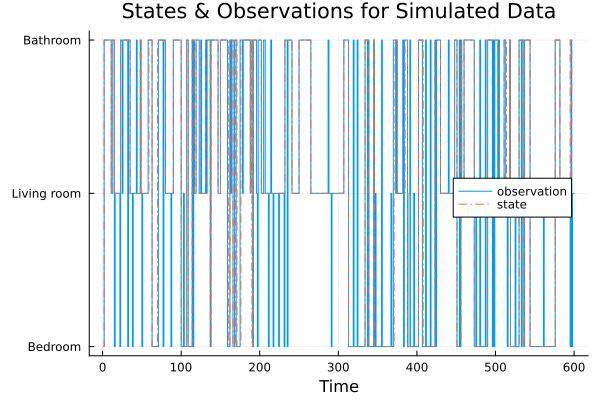

In [56]:
plot(title="States & Observations for Simulated Data")
# plot!(argmax.(_xSim), linetype=:steppre, linestyle=:solid, leg=:right, label="observation", xlabel="Time", yticks=([1,2,3], ["Bedroom", "Living room", "Bathroom"]))
plot!(argmax.(_yˢⁱᵐ), linetype=:steppre, linestyle=:solid, leg=:right, label="observation", xlabel="Time", yticks=([1,2,3], ["Bedroom", "Living room", "Bathroom"]))
# plot!(argmax.(_sSim), linetype=:steppre, linestyle=:dashdot, leg=:right, label="state", xlabel="Time", yticks=([1,2,3], ["Bedroom", "Living room", "Bathroom"]))
plot!(argmax.(_zˢⁱᵐ), linetype=:steppre, linestyle=:dashdot, leg=:right, label="state", xlabel="Time", yticks=([1,2,3], ["Bedroom", "Living room", "Bathroom"]))

### 4.4 Uncertainty Model

The uncertainty model is captured in the transition matrix $A$ and the observation matrix $B$.

### 4.5 Agent / Generative Model

#### 4.5.1 State variables

According to the agent the state of the system-under-steer/environment/generative process will be $s_t$ which is a 1-hot coded representation of the position of the Roomba.

#### 4.5.2 Decision variables

There will be no decision variables.

#### 4.5.3 Implementation of the Agent / Generative Model / Internal Model

Now it is time to build our model. As mentioned earlier, we will use Categorical distributions for the states and observations. To learn the $A$ and $B$ matrices we can use `MatrixDirichlet` priors. For the $A$-matrix, since we have no apriori idea how the roomba is actually going to move we will assume that it moves randomly. We can represent this by filling our `MatrixDirichlet` prior on $A$ with ones. Remember that this will get updated once we start learning, so it's fine if our initial guess is not quite accurate.
As for the observations, we have good reason to trust our Roomba's measurements. To represent this, we will add large values to the diagonal of our prior on $B$. However, we also acknowledge that the Roomba is not infallible, so we will add some noise on the off-diagonal entries.

Since we will use Variational Inference, we also have to specify inference constraints. We will use a structured variational approximation to the true posterior distribution, where we decouple the variational posterior over the states (`q(s_0, s)`) from the posteriors over the transition matrices (`q(A)` and `q(B)`). This dependency decoupling in the approximate posterior distribution ensures that inference is tractable. Let's build the model!

In [57]:
# Model specification
# @model function hidden_markov_model(n)
# @model function hidden_markov_model(N)
@model function hidden_markov_model(T) #.
    A ~ MatrixDirichlet(ones(3, 3))
    B ~ MatrixDirichlet([10.0 1.0 1.0; 
                         1.0 10.0 1.0; 
                         1.0 1.0 10.0 ])    
    s₀ ~ Categorical(fill(1.0/3.0, 3))
    s = randomvar(T)
    x = datavar(Vector{Float64}, T)
    
    sₖ₋₁ = s₀
    # for t in 1:T
    for k in 1:T
        s[k] ~ Transition(sₖ₋₁, A)
        x[k] ~ Transition(s[k], B)
        sₖ₋₁ = s[k]
    end
end

# Constraints specification
@constraints function hidden_markov_model_constraints()
    q(s₀, s, A, B) = q(s₀, s)q(A)q(B)
end

hidden_markov_model_constraints (generic function with 1 method)

Next, we define the agent and the time-stepping procedure.

In [58]:
# function create_agent(; T=20, 𝚃, x₊, s₀, ξ=0.5, σ=1e-4)
function create_agent(; T=20, s₀)
    # ## Set control priors
    # Ξ  = fill(ξ, 1, 1) ##Control prior variance
    # mᵤ = Vector{Float64}[ [ 0.0] for k=1:T ] ##Set control priors
    # Vᵤ = Matrix{Float64}[ Ξ for k=1:T ]

    # ## Set target/goal priors
    # Σ       = σ*diageye(4) ##Target/Goal prior variance
    # Σ[3, 3] = 1e4
    # Σ[4, 4] = 1e4
    # mₓ      = [zeros(4) for k=1:T] ##mean for x [vector]
    # mₓ[end] = x₊ ##Set prior mean to reach target/goal at t=T
    # Vₓ      = [huge*diageye(4) for k=1:T] ##Variance for x [matrix]
    # Vₓ[end] = Σ ##Set prior variance to reach target/goal at t=T

    # ## Set initial brain state prior
    # mₛ₍ₜ₋₁₎ = s₀
    # Vₛ₍ₜ₋₁₎ = tiny*diageye(4)

    # ## Set current inference results
    # result = nothing
    
    ## Bayesian inference by message passing
    ## The `infer` function is the heart of the agent
    ## It calls the `RxInfer.infer` function to perform Bayesian inference by message passing
    # compute = (υₜ::Float64, ŷₜ::Vector{Float64}) -> begin
    compute = (ŷₜ::Vector{Float64}) -> begin
        # mᵤ[1] = [υₜ] ## Register action with the generative model
        # Vᵤ[1] = fill(tiny, 1, 1) ## Clamp control prior to performed action

        # mₓ[1] = ŷₜ ## Register observation with the generative model
        # Vₓ[1] = tiny*diageye(4) ## Clamp target/goal prior to observation

        result = infer(
            model=hidden_markov_model(_Nᵃⁱ),
            # data=(x=_xˢⁱᵐ,),
            data=(x=_yˢⁱᵐ,),
            constraints=hidden_markov_model_constraints(),
            initmarginals = (
                A=vague(MatrixDirichlet, 3, 3), 
                B=vague(MatrixDirichlet, 3, 3), 
                s=vague(Categorical, 3)),
            returnvars = (    
                A=KeepLast(),
                B=KeepLast(),
                s=KeepLast()
            ),    
            iterations   =20,
            free_energy  =true
        );
    end

    # ## The `act` function returns the inferred best possible action
    # act = () -> begin
    #     if result !== nothing
    #         return mode(result.posteriors[:u][3])[1]
    #     else
    #         return 0.0 ## Without inference result we return some 'random' action
    #     end
    # end
    
    # ## The `future` function returns the inferred future states
    # future = () -> begin 
    #     if result !== nothing 
    #         return getindex.(mode.(result.posteriors[:s]), 1)
    #     else
    #         return zeros(T)
    #     end
    # end

    # ## The `slide` function modifies the `(mₛ₍ₜ₋₁₎, Vₛ₍ₜ₋₁₎` for the next step
    # ## and shifts (or slides) the array of future goals `(mₓ, Vₓ)` 
    # ## and inferred actions `(mᵤ, Vᵤ)`
    # slide = () -> begin
    #     (s, ) = result.returnval
        
    #     slide_msg_idx = 3 ## This index is model dependent
    #     (mₛ₍ₜ₋₁₎, Vₛ₍ₜ₋₁₎) = mean_cov(getrecent(messageout(s[2], slide_msg_idx)))

    #     mᵤ = circshift(mᵤ, -1)
    #     mᵤ[end] = [0.0]
    #     Vᵤ = circshift(Vᵤ, -1)
    #     Vᵤ[end] = Ξ

    #     mₓ = circshift(mₓ, -1)
    #     mₓ[end] = x₊ ##x_target
    #     Vₓ = circshift(Vₓ, -1)
    #     Vₓ[end] = Σ
    # end

    # return (act, future,   compute, slide)
    return (compute)
end    

create_agent (generic function with 1 method)

### 4.6 Agent Evaluation

Now it's time to perform inference and find out where the Roomba went in our absence. Did it remember to clean the bathroom?

We'll be using Variational Inference to perform inference, which means we need to set some initial marginals as a starting point. RxInfer makes this easy with the `vague` function, which provides an uninformative guess. If you have better ideas, you can try a different initial guess and see what happens.

Since we're only interested in the final result - the best guess about the Roomba's position - we'll only keep the last results. Let's start the inference process!

#### 4.6.1 Evaluate with simulated data

##### 4.6.1.1 Naive approach {N/A}

##### 4.6.1.2 Active inference approach

In [59]:
### Simulation parameters
## Total simulation time
# _Nᵃⁱ = 100
_Nᵃⁱ = 600

# ## Lookahead time horizon
# _Tᵃⁱ = 50 ## Lookahead time horizon

_Aᵃⁱ = [    
    0.9  0.0  0.1;
    0.0  0.9  0.1;
    0.1  0.1  0.8]
_Bᵃⁱ = [    
    0.9  0.05 0.05;
    0.05 0.9  0.05;
    0.05 0.05 0.9] 

# ## Initial state
# _s₀ = [-0.0, 0.0, -0.1, 3.0] ## initial state
_s₀ = [1.0, 0.0, 0.0] ## initial state


# ## Control prior variance value
# _ξ = 0.5

# ## Target prior variance value
# _σ = 1e-4

# ## Target/Goal state
# _x₊ = [100.0, 100.0, 0.0*π, 3.0]

3-element Vector{Float64}:
 1.0
 0.0
 0.0

In [60]:
### OVERRIDES

In [61]:
# resultSim = infer(
#     model=hidden_markov_model(_NSim),
#     data=(x=_xSim,),
#     constraints=hidden_markov_model_constraints(),
#     initmarginals = (
#         A=vague(MatrixDirichlet, 3, 3), 
#         B=vague(MatrixDirichlet, 3, 3), 
#         s=vague(Categorical, 3)),
#     returnvars = (    
#         A=KeepLast(),
#         B=KeepLast(),
#         s=KeepLast()
#     ),    
#     iterations   =20,
#     free_energy  =true
# );

That was fast! Let's take a look at our results. If we're successful, we should have a good idea about the actual layout of the apartment (a good posterior marginal over $A$) and about the uncertainty in the roomba's observations (A good posterior over $B$). Let's see if it worked

In [62]:
(execute_ai, observe_ai) = create_envir(; ## Let there be a world
    # Rᵃ=Rᵃ,
    A=_Aᵃⁱ,
    B=_Bᵃⁱ,
    # z₀=_s₀
    z₀=_s₀
)
# (act_ai, future_ai,   compute_ai, slide_ai) = create_agent(; ## Let there be an agent
(compute_ai) = create_agent(; ## Let there be an agent
    # T =_Tᵃⁱ,
    # Rᵃ=Rᵃ,
    # x₊=_x₊,
    s₀=_s₀,
    # ξ = _ξ,
    # σ = _σ
)

## Step through experimental protocol
# _agent_a = Vector{Float64}(undef, _Nˢⁱᵐ)         ## Actions
# _zᵃⁱ = Vector{Vector{Float64}}(undef, _Nᵃⁱ)         ## States
_sᵃⁱ = Vector{Vector{Float64}}(undef, _Nᵃⁱ)         ## States
# _agent_f = Vector{Vector{Float64}}(undef, _Nᵃⁱ) ## Predicted future
# _agent_x = Vector{Vector{Float64}}(undef, _Nˢⁱᵐ) ## Observations
# _yᵃⁱ = Vector{Vector{Float64}}(undef, _Nᵃⁱ) ## Observations
_xᵃⁱ = Vector{Vector{Float64}}(undef, _Nᵃⁱ) ## Observations
# _result = Vector{Vector{Float64}}(undef, _Nᵃⁱ)
# _result = Vector{Float64}(undef, _Nᵃⁱ)
for t = 1:_Nᵃⁱ
    ## 1. Act-Execute-Observe: #.execute() & observe() from create_envir()
    # _agent_a[t] = act_ai()     ## Invoke an action from the agent
    # _agent_f[t] = future_ai()  ## Fetch the predicted future states
                    # execute_ai(_agent_a[t]) ## The action influences hidden external states
    # _zˢⁱᵐ[t] = execute_sim(_zˢⁱᵐ[t]) ## The action influences hidden external states
    # _zᵃⁱ[t] = execute_sim() ## The action influences hidden external states
    _sᵃⁱ[t] = execute_ai() ## The action influences hidden external states
            #    execute_sim() ## The action influences hidden external states
    # _agent_x[t] = observe_ai() ## Observe the current environmental outcome (update p)
    # _yᵃⁱ[t] = observe_sim() ## Observe the current environmental outcome (update p)
    _xᵃⁱ[t] = observe_ai() ## Observe the current environmental outcome (update p)
    ## 2. Infer:
                #  compute_ai(_agent_a[t], _agent_x[t]) ## Infer beliefs from current model state (update q)
    # _result[t] = compute_ai(_agent_a[t], _agent_x[t]) ## Infer beliefs from current model state (update q)
    # _result[t] = compute_ai(_xᵃⁱ[t]) ## Infer beliefs from current model state (update q)
    ## 3. Slide:
                #  slide_ai() ## Prepare for next iteration
end

In [63]:
_sᵃⁱ

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]

In [64]:
_xᵃⁱ

600-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [1.0, 0.0, 0.0]
 [0.0, 0.0, 1.0]
 [1.0, 0.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]

In [65]:
println("Posterior Marginal for A:")
# _ASim_est = mean(resultSim.posteriors[:A])

_result = compute_ai([1.0, 0.0, 0.0])
# _result = compute_ai([0.0, 1.0, 0.0])
_ASim_est = mean(_result.posteriors[:A])

Posterior Marginal for A:


3×3 Matrix{Float64}:
 0.897154    0.00601595  0.0784621
 0.00609634  0.891404    0.0976006
 0.0967495   0.10258     0.823937

This compares well with:
```
ASim = [
0.9  0.0  0.1;
0.0  0.9  0.1;
0.1  0.1  0.8]
```


In [66]:
println("Posterior Marginal for B:")
# _BSim_est = mean(resultSim.posteriors[:B])

_result = compute_ai([1.0, 0.0, 0.0])
# _result = compute_ai([0.0, 1.0, 0.0])
_BSim_est = mean(_result.posteriors[:B])

Posterior Marginal for B:


3×3 Matrix{Float64}:
 0.872276   0.0587915  0.0706833
 0.0474132  0.883385   0.0228114
 0.0803105  0.057823   0.906505

This compares well with:
```
BSim = [
0.9  0.05 0.05;
0.05 0.9  0.05;
0.05 0.05 0.9] 
```

Finally, we can check if we were successful in keeping tabs on our Roomba's whereabouts. We can also check if our model has converged by looking at the Free Energy. 


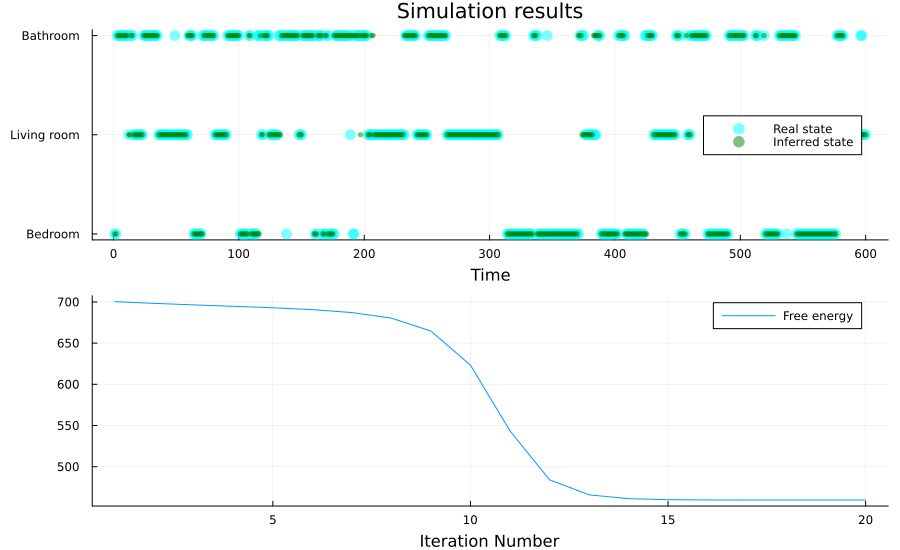

In [67]:
# p1 = scatter(argmax.(_sSim),
p1 = scatter(argmax.(_zˢⁱᵐ),
    title="Simulation results", 
    label="Real state", 
    legend=:right,
    xlabel="Time" ,
    yticks=([1,2,3],["Bedroom","Living room","Bathroom"]),
    markercolor=:cyan, #.
    markersize=6,
    # markerstrokecolor=:red, #.:blue
    # markeralpha=0, #.
    markerstrokewidth=0, #.
    # markerstrokealpha=.5, #.
    alpha=.5, #.    
    size=(900,550)
)
# p1 = scatter!(p1, argmax.(ReactiveMP.probvec.(resultSim.posteriors[:s])),
p1 = scatter!(p1, argmax.(ReactiveMP.probvec.(_result.posteriors[:s])),
    label="Inferred state",
    markercolor=:green, #.
    markersize=3,
    # markerstrokecolor=:blue, #.:blue
    # markeralpha=0, #.
    markerstrokewidth=0, #.
    # markerstrokealpha=.5, #.
    alpha=.5 #.    
)
# p2 = plot(resultSim.free_energy, 
p2 = plot(_result.free_energy, 
    label="Free energy",
    xlabel="Iteration Number"
)
plot(p1, p2, layout=@layout([ a; b ]))

## 5 Evaluation

In [68]:
#| hide
# _NFld = 468 # 9 years * 52 weeks/year
_Nᶠˡᵈ = 468 # 9 years * 52 weeks/year
# _AFld = [
_Aᶠˡᵈ = [
    0.6   0.05  0.1;
    0.25  0.9   0.1;
    0.15  0.05  0.8]
# _BFld = [
_Bᶠˡᵈ = [
    0.9  0.05 0.05;
    0.05 0.9  0.05;
    0.05 0.05 0.9]
# _s_0Fld = [1.0, 0.0, 0.0] ## initial state
_zᶠˡᵈ₀ = [1.0, 0.0, 0.0] ## initial state
# _xFld, _sFld = generate_data(_Nᶠˡᵈ, _Aᶠˡᵈ, _Bᶠˡᵈ, _zᶠˡᵈ₀)
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# ///////////////////////////////////////////////////////////
(execute_fld, observe_fld) = create_envir(; ## Let there be a world
    A=_Aᶠˡᵈ,
    B=_Bᶠˡᵈ,
    z₀=_zᶠˡᵈ₀
)

_zᶠˡᵈ = Vector{Vector{Float64}}(undef, _Nᶠˡᵈ) ## States
_yᶠˡᵈ = Vector{Vector{Float64}}(undef, _Nᶠˡᵈ) ## Observations
for t = 1:_Nᶠˡᵈ
    _zᶠˡᵈ[t] = execute_sim() ## The action influences hidden external states
    _yᶠˡᵈ[t] = observe_sim() ## Observe the current environmental outcome (update p)
end
# \\\\\\\\\\\\\\\\

# _df_s = DataFrame(mapreduce(permutedims, vcat, _sFld), :auto)
_df_z = DataFrame(mapreduce(permutedims, vcat, _zᶠˡᵈ), :auto)
# _df_s = rename(_df_s, :x1=>:Bedroom, :x2=>:LivingRoom, :x3=>:Bathroom)
_df_z = rename(_df_z, :x1=>:Bedroom, :x2=>:LivingRoom, :x3=>:Bathroom)
# _df_x = DataFrame(mapreduce(permutedims, vcat, _xFld), :auto)
_df_y = DataFrame(mapreduce(permutedims, vcat, _yᶠˡᵈ), :auto)
# _df_x = rename(_df_x, :x1=>:Bedroom, :x2=>:LivingRoom, :x3=>:Bathroom)
_df_y = rename(_df_y, :x1=>:Bedroom, :x2=>:LivingRoom, :x3=>:Bathroom)

## save to excel file
#+ XLSX.writetable("df.xlsx", collect(DataFrames.eachcol(df)), DataFrames.names(df))
# data = collect(DataFrames.eachcol(df_s))
# columnnames = DataFrames.names(df_s)
XLSX.openxlsx("roomba_state.xlsx", mode="w") do xf
    sheet = xf[1]
    # XLSX.writetable!(sheet, collect(DataFrames.eachcol(_df_s)), DataFrames.names(_df_s))
    XLSX.writetable!(sheet, collect(DataFrames.eachcol(_df_z)), DataFrames.names(_df_z))
end
XLSX.openxlsx("roomba_observation.xlsx", mode="w") do xf
    sheet = xf[1]
    # XLSX.writetable!(sheet, collect(DataFrames.eachcol(_df_x)), DataFrames.names(_df_x))
    XLSX.writetable!(sheet, collect(DataFrames.eachcol(_df_y)), DataFrames.names(_df_y))
end

The following data comes from the field ...:

In [70]:
# _xFld_df = DataFrame(XLSX.readtable("roomba_observation.xlsx", "Sheet1"));
_yFld_df = DataFrame(XLSX.readtable("roomba_observation.xlsx", "Sheet1"));
# _xFld_mat = Float64.(Matrix(_xFld_df))
_yFld_mat = Float64.(Matrix(_yFld_df))
# _xFld = [_xFld_mat[r, 1:end] for r in 1:size(_xFld_mat)[1]]
_yFld = [_yFld_mat[r, 1:end] for r in 1:size(_yFld_mat)[1]]

468-element Vector{Vector{Float64}}:
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 1.0, 0.0]

In [71]:
# _sFld_df = DataFrame(XLSX.readtable("roomba_state.xlsx", "Sheet1"));
_zFld_df = DataFrame(XLSX.readtable("roomba_state.xlsx", "Sheet1"));
# _sFld_mat = Float64.(Matrix(_sFld_df))
_zFld_mat = Float64.(Matrix(_zFld_df))
# _sFld = [_sFld_mat[r, 1:end] for r in 1:size(_sFld_mat)[1]]
_zFld = [_zFld_mat[r, 1:end] for r in 1:size(_zFld_mat)[1]]

468-element Vector{Vector{Float64}}:
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 0.0, 1.0]
 [0.0, 0.0, 1.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 ⋮
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]
 [0.0, 1.0, 0.0]

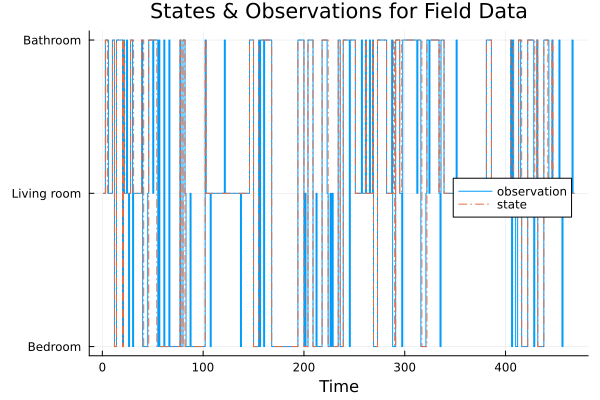

In [72]:
plot(title="States & Observations for Field Data")
# plot!(argmax.(_xFld), linetype=:steppre, linestyle=:solid, leg=:right, label="observation", xlabel="Time", yticks=([1,2,3], ["Bedroom", "Living room", "Bathroom"]))
plot!(argmax.(_yFld), linetype=:steppre, linestyle=:solid, leg=:right, label="observation", xlabel="Time", yticks=([1,2,3], ["Bedroom", "Living room", "Bathroom"]))
# plot!(argmax.(_sFld), linetype=:steppre, linestyle=:dashdot, leg=:right, label="state", xlabel="Time", yticks=([1,2,3], ["Bedroom", "Living room", "Bathroom"]))
plot!(argmax.(_zFld), linetype=:steppre, linestyle=:dashdot, leg=:right, label="state", xlabel="Time", yticks=([1,2,3], ["Bedroom", "Living room", "Bathroom"]))

In [73]:
_resultFld = infer(
    # model=hidden_markov_model(_NFld),
    model=hidden_markov_model(_Nᶠˡᵈ),
    # data=(x=_xFld,),
    data=(x=_yᶠˡᵈ,),
    constraints=hidden_markov_model_constraints(),
    initmarginals=(    
        A=vague(MatrixDirichlet, 3, 3), 
        B=vague(MatrixDirichlet, 3, 3), 
        s=vague(Categorical, 3)),
    returnvars=(    
        A=KeepLast(),
        B=KeepLast(),
        s=KeepLast()
    ),    
    iterations=25, #20, 
    free_energy=true
);

In [74]:
println("Posterior Marginal for A:")
_AFld_est = mean(_resultFld.posteriors[:A])


Posterior Marginal for A:


3×3 Matrix{Float64}:
 0.831617    0.011141   0.144923
 0.00974845  0.91995    0.0850497
 0.158635    0.0689087  0.770027

In [38]:
# println("Posterior Marginal for A:")
# _AFld_est = mean(_resultFld.posteriors[:A])


Posterior Marginal for A:


3×3 Matrix{Float64}:
 0.639578  0.0508166  0.0799558
 0.175403  0.87627    0.134016
 0.18502   0.0729133  0.786028

This compares well with:
```
AFld = [
    0.6   0.05  0.1;
    0.25  0.9   0.1;
    0.15  0.05  0.8]
```

In [75]:
println("Posterior Marginal for B:")
_BFld_est = mean(_resultFld.posteriors[:B])

Posterior Marginal for B:


3×3 Matrix{Float64}:
 0.896383   0.0334892  0.0413844
 0.0768703  0.908576   0.0526669
 0.0267463  0.0579343  0.905949

In [39]:
# println("Posterior Marginal for B:")
# _BFld_est = mean(_resultFld.posteriors[:B])

Posterior Marginal for B:


3×3 Matrix{Float64}:
 0.906092   0.0696547  0.0402358
 0.0287702  0.875053   0.0356966
 0.0651383  0.0552923  0.924068

This compares well with:
```
BFld = [
    0.9  0.05 0.05;
    0.05 0.9  0.05;
    0.05 0.05 0.9]
```

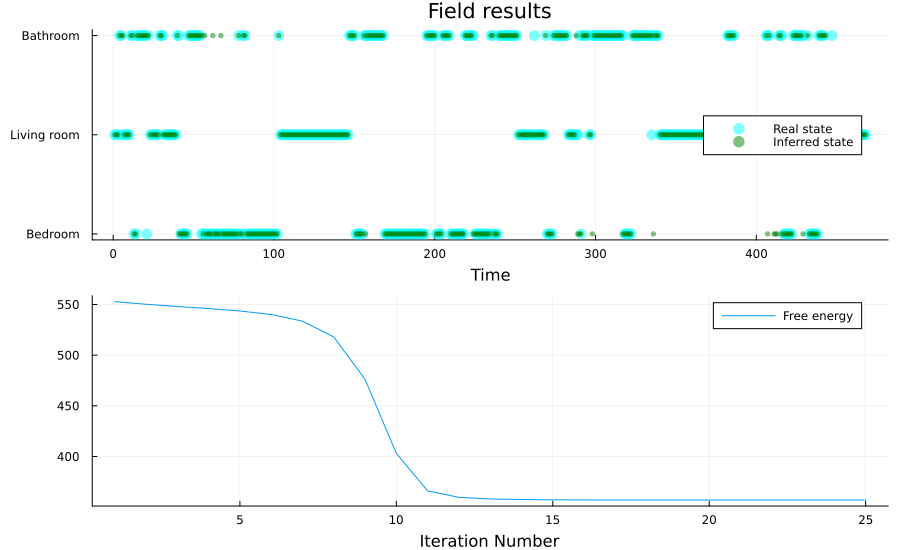

In [76]:
# _p1 = scatter(argmax.(_sFld), 
_p1 = scatter(argmax.(_zFld), 
    title="Field results", 
    label="Real state", 
    legend=:right,
    xlabel="Time" ,
    yticks=([1,2,3],["Bedroom","Living room","Bathroom"]),
    markercolor=:cyan, #.
    markersize=6,
    # markerstrokecolor=:red, #.:blue
    # markeralpha=0, #.
    markerstrokewidth=0, #.
    # markerstrokealpha=.5, #.
    alpha=.5, #.
    size=(900,550)
)
_p1 = scatter!(_p1, argmax.(ReactiveMP.probvec.(_resultFld.posteriors[:s])),
    label="Inferred state",
    markercolor=:green, #.
    markersize=3,
    # markerstrokecolor=:blue, #.:blue
    # markeralpha=0, #.
    markerstrokewidth=0, #.
    # markerstrokealpha=.5, #.
    alpha=.5 #.
)
_p2 = plot(_resultFld.free_energy, 
    label="Free energy",
    xlabel="Iteration Number"
)
plot(_p1, _p2, layout=@layout([ a; b ]))

Neat! Now you know how to track a Roomba if you ever need to. You also learned how to fit a Hidden Markov Model using `RxInfer` in the process.